# XGBoost vs GLM Comparison

Compares cross-validated pseudo-R² (pR²) between **XGBoost** and **GLM** (pyglmnet, softplus distribution).

Both models are parameterised identically:
- `cov_history=True`, `spike_history=False`
- `window=time_bs`, `n_filters=5`, `max_time=1000 ms`

This means both receive the same expanded covariate matrix (current-bin values + raised cosine filter projections of each covariate over the past 1000 ms). The only difference is the model architecture: a gradient-boosted tree ensemble vs a regularised generalised linear model.

Starting point: **M29 D23, OF1 session**. A sample of grid cells (GC) and non-grid spatial cells (NGS) are used as target cells.

Baselines tested:
- `pos` — 2D position (P_x, P_y)
- `hd` — head direction
- `speed` — running speed
- `lfp` — theta power
- `full` — pos + hd + speed + lfp
- `full + N GC cells` — full baseline plus N covariate grid cells
- `full + N NGS cells` — full baseline plus N covariate NGS cells

Plots:
1. Scatter: XGBoost pR² vs GLM pR² per baseline (one point per cell)
2. Bar chart: mean ± SEM pR² per baseline, both models
3. Gain from covariate cells: pR² improvement over `full` baseline
4. Paired comparison per baseline with Wilcoxon test

In [1]:
import importlib
import numpy as np
import pandas as pd
import pynapple as nap
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# pyglmnet uses np.float which was removed in NumPy 2.0
np.float = float

# Force reload so any edits to mlencoding.py take effect without a kernel restart
import spatial_manifolds.mlencoding
importlib.reload(spatial_manifolds.mlencoding)
from spatial_manifolds.mlencoding import MLencoding, poisson_pseudoR2

from spatial_manifolds.detect_grids import (
    compute_of_tcs, classify_cells_both_sessions, get_theta_trace
)
from spatial_manifolds.anaylsis_parameters import time_bs

MOUSE   = 29
DAY     = 23
SESSION = 'OF1'
N_TARGET = 10   # target cells sampled per type (GC + NGS)
N_COV    = 10    # covariate cells per type added to 'full' baseline

source_path = '/Users/harryclark/Downloads/COHORT12/'

print(f'time_bs = {time_bs} ms')

time_bs = 10 ms


## Load data

In [2]:
gcs, ngs, all_cells = classify_cells_both_sessions(
    MOUSE, DAY, source_path=source_path
)

tcs, tcs_time, beh_OF, clusters_OF, ep = compute_of_tcs(
    MOUSE, DAY,
    apply_zscore=False, apply_guassian_filter=False,
    source_path=source_path, session=SESSION
)

last_bin = clusters_OF[clusters_OF.index[0]].count(
    bin_size=time_bs, time_units='ms'
).index[-1]
ep = nap.IntervalSet(start=0, end=last_bin, time_units='s')

def _bin(arr):
    x = np.array(arr.bin_average(bin_size=time_bs, time_units='ms', ep=ep))
    if np.any(np.isnan(x)):
        x = np.array(pd.Series(x).ffill().bfill())
    return x

pos_x = _bin(beh_OF['P_x'])
pos_y = _bin(beh_OF['P_y'])
speed = _bin(beh_OF['S'])
hd    = _bin(beh_OF['H'])

print(f'GC cells: {len(gcs)},  NGS cells: {len(ngs)}')
print(f'Trace length: {len(pos_x)} bins ({len(pos_x)*time_bs/1000:.1f} s)')

GC cells: 27,  NGS cells: 120
Trace length: 120039 bins (1200.4 s)


## Select target cells and load theta

Sample `N_TARGET` GC and NGS cells. Covariate cells are drawn from the remaining pool of each type.

In [3]:
gc_ids_all  = [c for c in gcs['cluster_id'].values  if c in tcs_time]
ngs_ids_all = [c for c in ngs['cluster_id'].values  if c in tcs_time]

np.random.seed(42)
gc_target  = list(np.random.choice(gc_ids_all,  min(N_TARGET, len(gc_ids_all)),  replace=False))
ngs_target = list(np.random.choice(ngs_ids_all, min(N_TARGET, len(ngs_ids_all)), replace=False))

target_ids    = gc_target + ngs_target
target_labels = ['GC'] * len(gc_target) + ['NGS'] * len(ngs_target)

# Covariate pools: exclude target cells from each type
cov_gc_ids  = [c for c in gc_ids_all  if c not in target_ids][:N_COV]
cov_ngs_ids = [c for c in ngs_ids_all if c not in target_ids][:N_COV]

# Preload theta for each target cell
theta_traces = {}
for cid in target_ids:
    try:
        th = get_theta_trace(
            MOUSE, DAY, cid,
            time_bs=50, resample_bs=time_bs,
            session_type='OF1', source_path=source_path
        )
        theta_traces[cid] = np.array(th)
    except Exception as e:
        print(f'  theta unavailable for c{cid}: {e}')
        theta_traces[cid] = None

print(f'Target GC ids:  {gc_target}')
print(f'Target NGS ids: {ngs_target}')
print(f'Cov GC ids:     {cov_gc_ids}')
print(f'Cov NGS ids:    {cov_ngs_ids}')

Target GC ids:  [np.int64(210), np.int64(217), np.int64(211), np.int64(389), np.int64(132), np.int64(214), np.int64(341), np.int64(343), np.int64(216), np.int64(420)]
Target NGS ids: [np.int64(297), np.int64(414), np.int64(239), np.int64(157), np.int64(292), np.int64(169), np.int64(244), np.int64(383), np.int64(363), np.int64(133)]
Cov GC ids:     [144, 160, 184, 191, 194, 202, 205, 213, 219, 332]
Cov NGS ids:    [20, 24, 28, 29, 30, 32, 33, 34, 53, 61]


## Run XGBoost and GLM across baselines

Both models use **identical parameterisation**: covariate history with raised cosine filters (`n_filters=5`, `max_time=1000 ms`). The `get_all_with_history` method inside `MLencoding.fit_cv` expands the covariate matrix the same way for both — so each model sees exactly the same features. Architecture is the only variable.

Both use 10-fold contiguous cross-validation (`continuous_folds=True`).

In [4]:
HISTORY_KWARGS = dict(
    cov_history=True, spike_history=False,
    window=time_bs, n_filters=5, max_time=1000
)

xgb_model = MLencoding(tunemodel='xgboost', **HISTORY_KWARGS)
glm_model = MLencoding(tunemodel='glm',     **HISTORY_KWARGS)

# Installed pyglmnet expects reg_lambda to be a scalar, not an array.
# The default path goes from ~0.05 → ~0.0001; use the least-regularised
# endpoint (0.0001) to match what model[-1] was intended to select.
glm_model.set_params({'reg_lambda': 0.0001})

def _zscore(arr):
    """Z-score a 1-D array; returns zeros if std==0."""
    sd = np.nanstd(arr)
    return (arr - np.nanmean(arr)) / sd if sd > 0 else np.zeros_like(arr)

results = []

for tgt_id, tgt_label in zip(target_ids, target_labels):
    y = np.array(tcs_time[tgt_id])
    T = len(y)

    px  = pos_x[:T]
    py  = pos_y[:T]
    sp  = speed[:T]
    hd_ = hd[:T]

    raw_th = theta_traces[tgt_id]
    if raw_th is not None:
        theta = raw_th[:T] if len(raw_th) >= T else np.pad(raw_th, (0, T - len(raw_th)))
    else:
        theta = np.zeros(T)

    # Z-score behavioural covariates so the GLM gradient doesn't blow up.
    # XGBoost is split-based and scale-invariant, so this has no effect on it.
    px_z = _zscore(px);  py_z = _zscore(py)
    sp_z = _zscore(sp);  hd_z = _zscore(hd_);  th_z = _zscore(theta)

    # Cell spike-count covariates: z-score each cell independently
    def _zscore_mat(mat):
        out = np.zeros_like(mat, dtype=float)
        for j in range(mat.shape[1]):
            out[:, j] = _zscore(mat[:, j])
        return out

    cov_gc_mat  = np.vstack([np.array(tcs_time[c])[:T] for c in cov_gc_ids]).T   if cov_gc_ids  else np.zeros((T, 0))
    cov_ngs_mat = np.vstack([np.array(tcs_time[c])[:T] for c in cov_ngs_ids]).T  if cov_ngs_ids else np.zeros((T, 0))
    if cov_gc_mat.shape[1]  > 0: cov_gc_mat  = _zscore_mat(cov_gc_mat)
    if cov_ngs_mat.shape[1] > 0: cov_ngs_mat = _zscore_mat(cov_ngs_mat)

    X_full = np.column_stack([px_z, py_z, hd_z, sp_z, th_z])

    BASELINES = {
        'pos':   np.column_stack([px_z, py_z]),
        'hd':    hd_z[:, None],
        'speed': sp_z[:, None],
        'lfp':   th_z[:, None],
        'full':  X_full,
        f'full+{N_COV}GC':  np.column_stack([X_full, cov_gc_mat])  if cov_gc_mat.shape[1]  > 0 else X_full,
        f'full+{N_COV}NGS': np.column_stack([X_full, cov_ngs_mat]) if cov_ngs_mat.shape[1] > 0 else X_full,
    }

    for bl_name, X_bl in BASELINES.items():
        print(f'  c{tgt_id} ({tgt_label})  [{bl_name}]', end='  ')

        _, pr2_xgb = xgb_model.fit_cv(X_bl, y, verbose=0, continuous_folds=True)
        _, pr2_glm = glm_model.fit_cv(X_bl, y, verbose=0, continuous_folds=True)

        pr2_xgb_mean = float(np.nanmean(pr2_xgb))
        pr2_glm_mean = float(np.nanmean(pr2_glm))
        print(f'XGB={pr2_xgb_mean:.3f}  GLM={pr2_glm_mean:.3f}')

        results.append(dict(
            target_id=tgt_id, cell_type=tgt_label, baseline=bl_name,
            pr2_xgb=pr2_xgb_mean, pr2_glm=pr2_glm_mean
        ))

df = pd.DataFrame(results)
df.head(10)

  c210 (GC)  [pos]  XGB=0.003  GLM=0.000
  c210 (GC)  [hd]  XGB=-0.004  GLM=-0.000
  c210 (GC)  [speed]  XGB=0.004  GLM=0.007
  c210 (GC)  [lfp]  XGB=0.017  GLM=0.017
  c210 (GC)  [full]  XGB=0.025  GLM=0.024
  c210 (GC)  [full+10GC]  XGB=0.030  GLM=0.027
  c210 (GC)  [full+10NGS]  XGB=0.041  GLM=0.038
  c217 (GC)  [pos]  XGB=0.008  GLM=-0.203
  c217 (GC)  [hd]  XGB=-0.003  GLM=0.000
  c217 (GC)  [speed]  XGB=-0.002  GLM=0.000
  c217 (GC)  [lfp]  XGB=0.009  GLM=0.009
  c217 (GC)  [full]  XGB=0.015  GLM=-0.356
  c217 (GC)  [full+10GC]  XGB=0.051  GLM=-0.350
  c217 (GC)  [full+10NGS]  XGB=0.023  GLM=-0.279
  c211 (GC)  [pos]  XGB=0.002  GLM=0.000
  c211 (GC)  [hd]  XGB=-0.002  GLM=-0.000
  c211 (GC)  [speed]  XGB=0.009  GLM=0.009
  c211 (GC)  [lfp]  XGB=0.055  GLM=0.052
  c211 (GC)  [full]  XGB=0.063  GLM=0.060
  c211 (GC)  [full+10GC]  XGB=0.073  GLM=0.070
  c211 (GC)  [full+10NGS]  XGB=0.105  GLM=0.095
  c389 (GC)  [pos]  XGB=0.032  GLM=0.004
  c389 (GC)  [hd]  XGB=0.005  GLM=0.004
  c

,target_id,cell_type,baseline,pr2_xgb,pr2_glm
0,210,GC,pos,0.003075,0.000248
1,210,GC,hd,-0.004015,-0.000216
2,210,GC,speed,0.004308,0.007004
3,210,GC,lfp,0.016703,0.017158
4,210,GC,full,0.025193,0.023695
5,210,GC,full+10GC,0.029659,0.027218
6,210,GC,full+10NGS,0.041038,0.037676
7,217,GC,pos,0.007532,-0.203127
8,217,GC,hd,-0.002885,0.000304
9,217,GC,speed,-0.002483,0.000087


## Plot 1 — Scatter: XGBoost vs GLM pR² per baseline

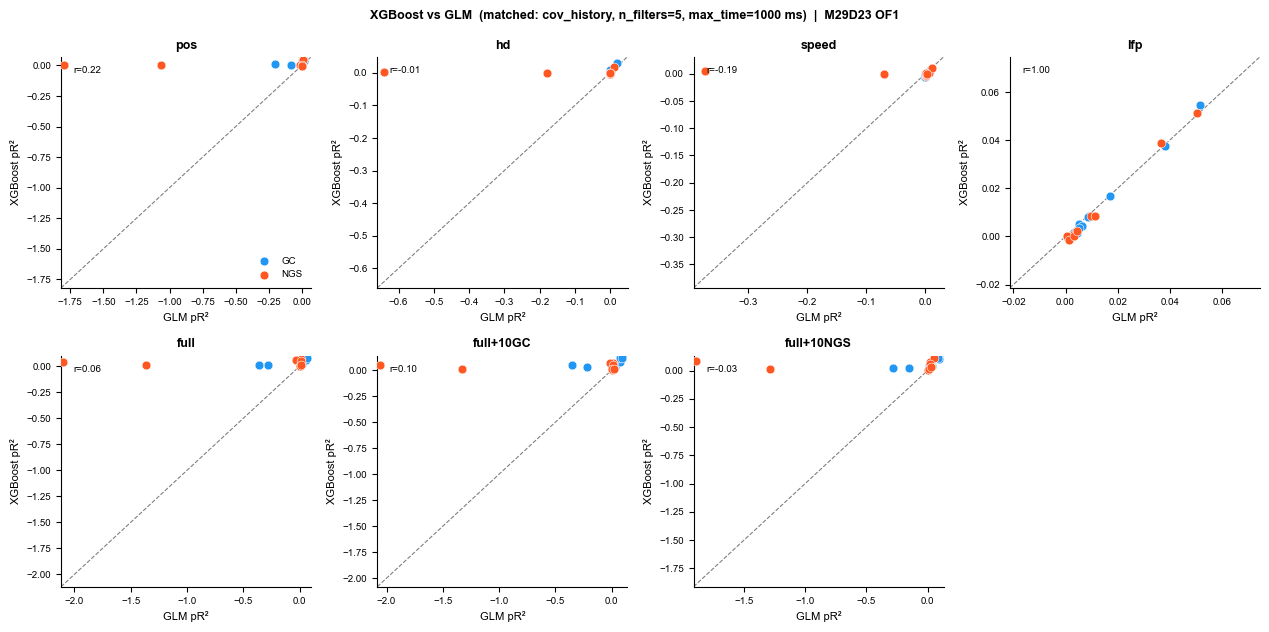

In [5]:
baseline_order = ['pos', 'hd', 'speed', 'lfp', 'full',
                  f'full+{N_COV}GC', f'full+{N_COV}NGS']
n_bl  = len(baseline_order)
ncols = 4
nrows = int(np.ceil(n_bl / ncols))

color_map = {'GC': '#2196F3', 'NGS': '#FF5722'}

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
axes = np.array(axes).flatten()

for i, bl in enumerate(baseline_order):
    ax  = axes[i]
    sub = df[df['baseline'] == bl]

    all_vals = pd.concat([sub['pr2_xgb'], sub['pr2_glm']]).dropna()
    lim = (min(0, all_vals.min()) - 0.02, all_vals.max() + 0.02) if len(all_vals) else (0, 1)

    ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.5, zorder=0)

    for ct, col in color_map.items():
        s = sub[sub['cell_type'] == ct]
        ax.scatter(s['pr2_glm'], s['pr2_xgb'], color=col, s=40,
                   edgecolors='white', linewidths=0.4, label=ct, zorder=3)

    if len(sub) >= 3:
        r, p = stats.pearsonr(sub['pr2_glm'].fillna(0), sub['pr2_xgb'].fillna(0))
        ax.text(0.05, 0.93, f'r={r:.2f}', transform=ax.transAxes, fontsize=7)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('GLM pR²', fontsize=8)
    ax.set_ylabel('XGBoost pR²', fontsize=8)
    ax.set_title(bl, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    if i == 0:
        ax.legend(fontsize=7, frameon=False)

for ax in axes[n_bl:]:
    ax.set_visible(False)

fig.suptitle(
    f'XGBoost vs GLM  (matched: cov_history, n_filters=5, max_time=1000 ms)  |  M{MOUSE}D{DAY} {SESSION}',
    fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## Plot 2 — Bar chart: mean ± SEM pR² per baseline, both models

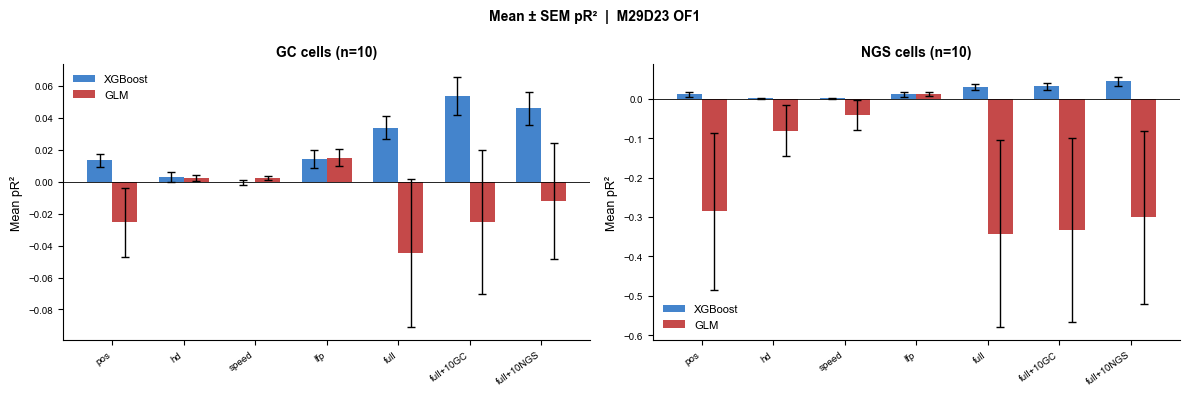

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, ct in zip(axes, ['GC', 'NGS']):
    sub = df[df['cell_type'] == ct]
    x   = np.arange(len(baseline_order))
    width = 0.35

    for offset, col_key, label, color in [
        (-width/2, 'pr2_xgb', 'XGBoost', '#1565C0'),
        ( width/2, 'pr2_glm',  'GLM',     '#B71C1C'),
    ]:
        means = [sub[sub['baseline'] == bl][col_key].mean() for bl in baseline_order]
        sems  = [sub[sub['baseline'] == bl][col_key].sem()  for bl in baseline_order]
        ax.bar(x + offset, means, width, yerr=sems, label=label,
               color=color, alpha=0.8, capsize=3, error_kw={'linewidth': 1})

    ax.axhline(0, color='k', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_order, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Mean pR²', fontsize=9)
    ax.set_title(f'{ct} cells (n={sub["target_id"].nunique()})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)

fig.suptitle(f'Mean ± SEM pR²  |  M{MOUSE}D{DAY} {SESSION}',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Plot 3 — pR² gain: covariate cells vs full baseline

Shows how much each model benefits from adding covariate cells beyond the full behavioural baseline.

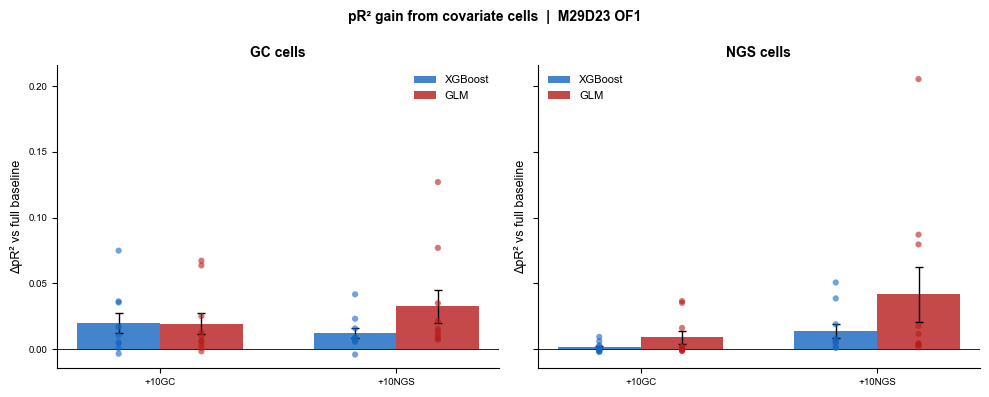

In [7]:
full_key = 'full'
cell_baselines = [f'full+{N_COV}GC', f'full+{N_COV}NGS']

# Compute gain = pR2(cell model) - pR2(full baseline), per cell
gain_rows = []
for tgt_id, tgt_label in zip(target_ids, target_labels):
    cell_df = df[df['target_id'] == tgt_id]
    full_row = cell_df[cell_df['baseline'] == full_key]
    if full_row.empty:
        continue
    pr2_full_xgb = full_row['pr2_xgb'].values[0]
    pr2_full_glm = full_row['pr2_glm'].values[0]

    for bl in cell_baselines:
        row = cell_df[cell_df['baseline'] == bl]
        if row.empty:
            continue
        gain_rows.append(dict(
            target_id=tgt_id, cell_type=tgt_label, cov_type=bl,
            gain_xgb=row['pr2_xgb'].values[0] - pr2_full_xgb,
            gain_glm=row['pr2_glm'].values[0]  - pr2_full_glm,
        ))

gain_df = pd.DataFrame(gain_rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, ct in zip(axes, ['GC', 'NGS']):
    sub = gain_df[gain_df['cell_type'] == ct]
    x   = np.arange(len(cell_baselines))
    width = 0.35

    for offset, col_key, label, color in [
        (-width/2, 'gain_xgb', 'XGBoost', '#1565C0'),
        ( width/2, 'gain_glm',  'GLM',     '#B71C1C'),
    ]:
        means = [sub[sub['cov_type'] == bl][col_key].mean() for bl in cell_baselines]
        sems  = [sub[sub['cov_type'] == bl][col_key].sem()  for bl in cell_baselines]
        ax.bar(x + offset, means, width, yerr=sems, label=label,
               color=color, alpha=0.8, capsize=3, error_kw={'linewidth': 1})

        # individual cell dots
        for j, bl in enumerate(cell_baselines):
            vals = sub[sub['cov_type'] == bl][col_key].values
            ax.scatter(np.full(len(vals), x[j] + offset), vals,
                       color=color, s=20, zorder=4, alpha=0.6, edgecolors='none')

    ax.axhline(0, color='k', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([bl.replace('full+', '+') for bl in cell_baselines],
                       fontsize=9)
    ax.set_ylabel('ΔpR² vs full baseline', fontsize=9)
    ax.set_title(f'{ct} cells', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)

fig.suptitle(f'pR² gain from covariate cells  |  M{MOUSE}D{DAY} {SESSION}',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Plot 4 — Paired comparison: XGBoost vs GLM per cell, per baseline

Each line connects the same cell's GLM and XGBoost pR² — highlights consistent direction of difference.

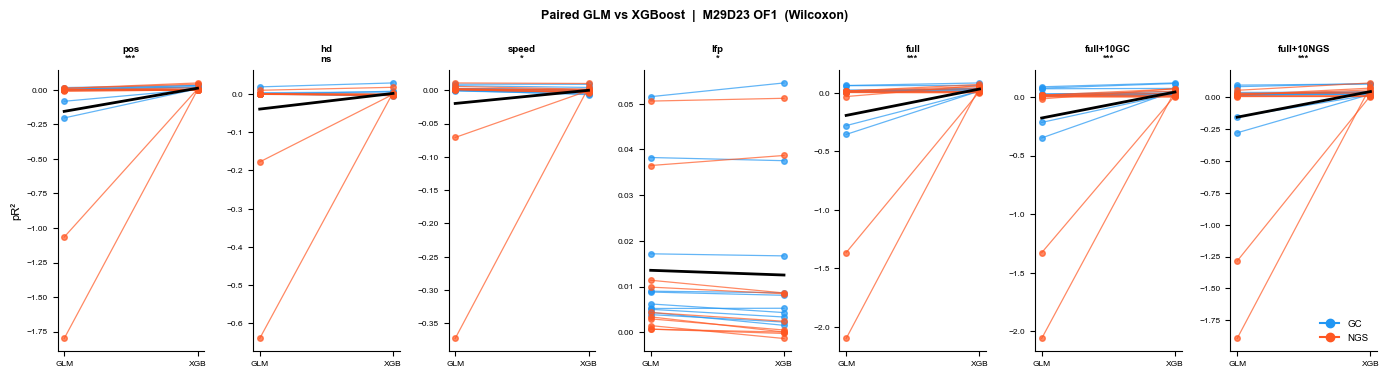

In [8]:
fig, axes = plt.subplots(1, len(baseline_order), figsize=(len(baseline_order) * 2.0, 3.8),
                         sharey=False)

for ax, bl in zip(axes, baseline_order):
    sub = df[df['baseline'] == bl]

    for _, row in sub.iterrows():
        col = color_map[row['cell_type']]
        ax.plot([0, 1], [row['pr2_glm'], row['pr2_xgb']],
                '-o', color=col, markersize=4, linewidth=0.9, alpha=0.7)

    # mean line
    ax.plot([0, 1], [sub['pr2_glm'].mean(), sub['pr2_xgb'].mean()],
            'k-', linewidth=2.0, zorder=5)

    stat, pval = stats.wilcoxon(sub['pr2_xgb'].fillna(0), sub['pr2_glm'].fillna(0))
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ax.set_title(f'{bl}\n{sig}', fontsize=7, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['GLM', 'XGB'], fontsize=8)
    ax.set_ylabel('pR²' if bl == baseline_order[0] else '', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=6)

# legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker='o', linewidth=1.5, label=l)
           for l, c in color_map.items()]
axes[-1].legend(handles=handles, fontsize=7, frameon=False, loc='lower right')

fig.suptitle(f'Paired GLM vs XGBoost  |  M{MOUSE}D{DAY} {SESSION}  (Wilcoxon)',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()